In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
# Remplace le chemin par celui de ton fichier CSV
df = pd.read_csv("Property_Prices_in_Tunisia.csv")

print(df.shape)
print(df.head())



(12748, 9)
                category  room_count  bathroom_count   size      type  \
0     Terrains et Fermes        -1.0            -1.0   -1.0  À Vendre   
1     Terrains et Fermes        -1.0            -1.0   -1.0  À Vendre   
2           Appartements         2.0             1.0   80.0   À Louer   
3  Locations de vacances         1.0             1.0   90.0   À Louer   
4           Appartements         2.0             2.0  113.0  À Vendre   

      price    city         region  log_price  
0  100000.0  Ariana         Raoued   5.000000  
1  316000.0  Ariana  Autres villes   5.499687  
2     380.0  Ariana  Autres villes   2.579784  
3      70.0  Ariana  Autres villes   1.845098  
4  170000.0  Ariana   Ariana Ville   5.230449  


In [20]:
import sys
!{sys.executable} -m pip install xgboost --user



In [71]:

print(sorted(df['category'].unique()))

['Appartements', 'Bureaux et Plateaux', 'Colocations', 'Locations de vacances', 'Magasins, Commerces et Locaux industriels', 'Maisons et Villas']


In [25]:
# AFFICHAGE COMPLÈT : chaque city → liste régions
city_regions = df.groupby('city')['region'].unique()
for city, regions in city_regions.items():
    print(f"🏙️  {city:25} → {list(regions)}")

🏙️  Ariana                    → ['Autres villes', 'Ariana Ville', 'Borj Louzir', 'Chotrana', "Jardins D'el Menzah", 'Raoued', 'Ennasr', 'Ghazela', 'La Soukra', 'Ariana', 'Mnihla', 'Ettadhamen', 'Sidi Thabet']
🏙️  Ben arous                 → ['Fouchana', 'Mornag', 'Mégrine', 'Medina Jedida', 'El Mourouj', 'Hammam Lif', 'Autres villes', 'Radès', 'Mohamedia', 'Boumhel', 'Hammam Chott', 'Ezzahra', 'Ben arous']
🏙️  Bizerte                   → ['Bizerte', 'Bizerte Nord', 'Autres villes', 'Ras Jebel', 'Mateur', 'Zarzouna', 'Ghar El Melh', 'Menzel Bourguiba', 'Bizerte Sud']
🏙️  Béja                      → ['Béja', 'Béja Nord', 'Autres villes', 'Testour', 'Téboursouk', 'Medjez el-Bab', 'Béja Sud']
🏙️  Gabès                     → ['Gabès Médina', 'Autres villes', 'Gabès', 'Gabès Sud', 'Métouia', 'Gabès Ouest', 'Nouvelle Matmata', 'El Hamma', 'Mareth']
🏙️  Gafsa                     → ['Gafsa Sud', 'Autres villes', 'Oum El Araies', 'Métlaoui', 'El Guettar', 'Gafsa', 'Gafsa Nord']
🏙️  Jendouba     

🎯 PROJET MACHINE LEARNING - PRIX IMMOBILIER TUNISIE

=== 1. DESCRIPTION DU DATASET ===
📊 Forme initiale: 12748 lignes, 9 colonnes
📋 Colonnes: ['category', 'room_count', 'bathroom_count', 'size', 'type', 'price', 'city', 'region', 'log_price']

📈 Stats descriptives:
         room_count  bathroom_count          size         price
count  12748.000000    12748.000000  12748.000000  1.274800e+04
mean       1.759649        0.759884    130.896219  1.601575e+07
std        2.171468        1.264812    184.074990  1.016644e+09
min       -1.000000       -1.000000     -1.000000  1.000000e+01
25%       -1.000000       -1.000000     -1.000000  8.500000e+02
50%        2.000000        1.000000     95.000000  8.975000e+04
75%        3.000000        1.000000    150.000000  2.600000e+05
max       20.000000       10.000000   2000.000000  1.000000e+11

❓ Valeurs manquantes initiales:
category          0
room_count        0
bathroom_count    0
size              0
type              0
price             0
city 

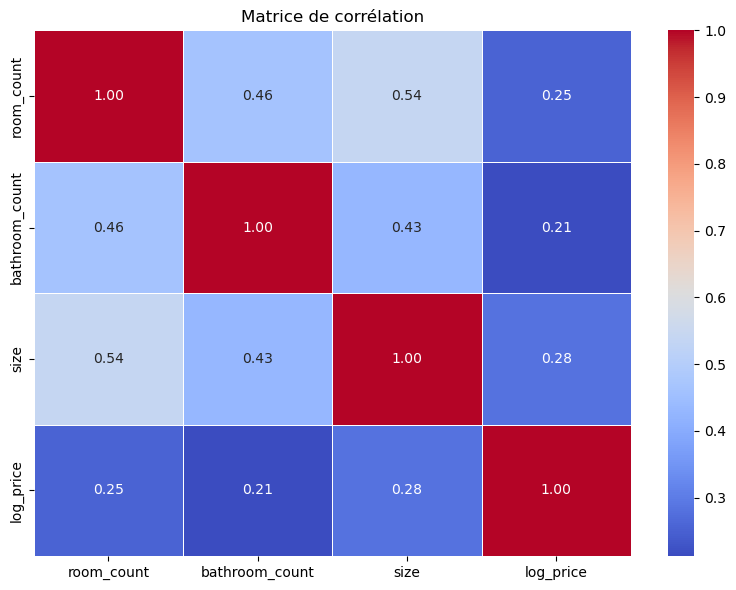

📊 Train : 5593 / Test : 1399

🔹 Entraînement du modèle : Linear Regression


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


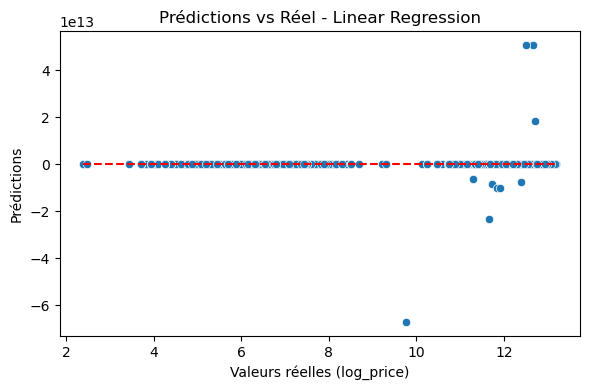

RMSE : 2788020296979.023
R2   : -900442109554395222900736.000

🔹 Entraînement du modèle : Random Forest


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


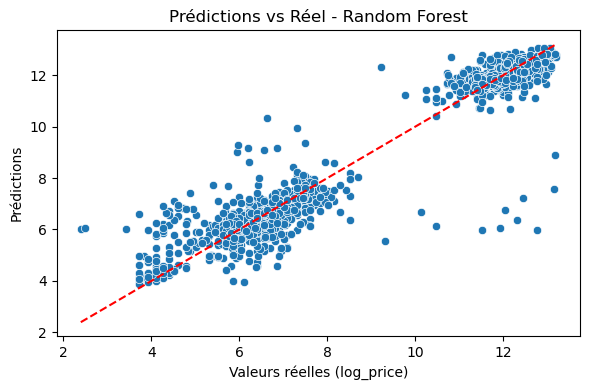

RMSE : 0.792
R2   : 0.927

🔹 Entraînement du modèle : XGBoost


C:\Users\Hp\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


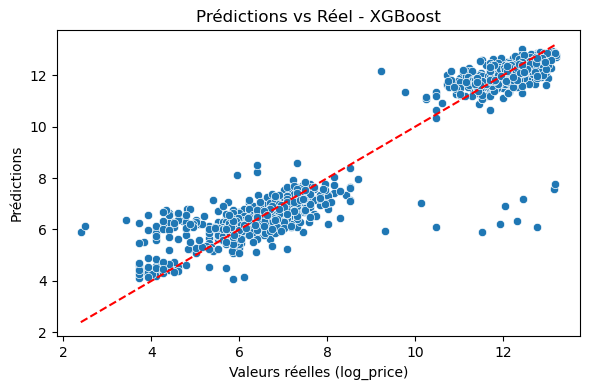

RMSE : 0.733
R2   : 0.938

📊 Comparaison des modèles :
                           RMSE            R2
XGBoost            7.333180e-01  9.377057e-01
Random Forest      7.922262e-01  9.272953e-01
Linear Regression  2.788020e+12 -9.004421e+23

🎉 Tout est prêt ! Modèle, scaler et données sauvegardés.


In [3]:
# =============================================
# PROJET MACHINE LEARNING - PRIX IMMOBILIER TUNISIE
# =============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

print("🎯 PROJET MACHINE LEARNING - PRIX IMMOBILIER TUNISIE")
print("="*60)


# ===========================================
# 1. DESCRIPTION DATASET
# ===========================================
print("\n=== 1. DESCRIPTION DU DATASET ===")
df = pd.read_csv('Property_Prices_in_Tunisia.csv')
print(f"📊 Forme initiale: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"📋 Colonnes: {df.columns.tolist()}")
print("\n📈 Stats descriptives:")
print(df[['room_count', 'bathroom_count', 'size', 'price']].describe())
print("\n❓ Valeurs manquantes initiales:")
print(df.isnull().sum())



print(f"🔍 Nombre de doublons initiaux: {df.duplicated().sum()}")
print(f"🔍 Nombre de 'Terrains et Fermes': {(df['category'] == 'Terrains et Fermes').sum()}")



# Skewness des variables numériques principales
print("\n📊 Skewness (asymétrie) des variables:")
print(f"  price       : {df['price'].skew():.3f}")
print(f"  size        : {df['size'].skew():.3f}")







# ==================================================
# 2. NETTOYAGE
# ==================================================
# Suppression "Terrains et Fermes" et doublons
df = df[df["category"] != "Terrains et Fermes"].drop_duplicates()
print(f"✅ Après suppression Terrains et duplication : {df.shape}")


# Normalisation colonne "type" pour eviter l'erreur de l'encodage 
df["type"] = df["type"].str.strip().str.lower().replace({"à vendre": "a_vendre", "à louer": "a_louer"})




# ==================================================
# 3. SUPPRESSION DES OUTLIERS (IQR)  IQR = InterQuartile Range
# ==================================================
def remove_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[col] >= Q1 - 1.5*IQR) & (data[col] <= Q3 + 1.5*IQR)]

df = remove_outliers(df, "price")
df = remove_outliers(df, "size")









# ==================================================
# 4. TRANSFORMATION DE LA CIBLE
# ==================================================
df["log_price"] = np.log1p(df["price"])




# ==================================================
# 5. ENCODAGE VARIABLES CATÉGORIELLES
# ==================================================
le_type = LabelEncoder()
df["type_encoded"] = le_type.fit_transform(df["type"])

# One-hot encoding pour city, region, category
df_encoded = pd.get_dummies(df, columns=["city", "region", "category"], drop_first=True)





# ==================================================
# 6. DÉFINITION DES FEATURES ET TARGET
# ==================================================
numerical_features = ["room_count", "bathroom_count", "size", "type_encoded"]
X = df_encoded[numerical_features + 
               [c for c in df_encoded.columns if c.startswith(("city_", "region_", "category_"))]]
y = df["log_price"]





# ==================================================
# 7. NORMALISATION DES FEATURES
# ==================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




# ==================================================
# 8. MATRICE DE CORRÉLATION
# ==================================================
corr_features = ["room_count", "bathroom_count", "size", "log_price"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()




# ==================================================
# 9. TRAIN / TEST SPLIT
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"📊 Train : {X_train.shape[0]} / Test : {X_test.shape[0]}")





# ==================================================
# 10. DÉFINITION ET ENTRAÎNEMENT DES MODÈLES
# ==================================================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n🔹 Entraînement du modèle : {name}")
  
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {"RMSE": rmse, "R2": r2}
    
    # Visualisation des prédictions
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.xlabel("Valeurs réelles (log_price)")
    plt.ylabel("Prédictions")
    plt.title(f"Prédictions vs Réel - {name}")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.tight_layout()
    plt.show()
    
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.3f}")






# ==================================================
# 11. COMPARAISON DES MODÈLES
# ==================================================
results_df = pd.DataFrame(results).T.sort_values(by="R2", ascending=False)
print("\n📊 Comparaison des modèles :")
print(results_df)

# Sélection du meilleur modèle (XGBoost ici)
best_model = models["XGBoost"]







# ==================================================
# 12. SAUVEGARDE DU MEILLEUR MODÈLE ET DATA
# ==================================================
joblib.dump(best_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
pd.DataFrame(X_scaled, columns=X.columns).to_csv("X_clean.csv", index=False)
y.to_csv("y_clean.csv", index=False)
df.to_csv("dataset_nettoye.csv", index=False)

print("\n🎉 Tout est prêt ! Modèle, scaler et données sauvegardés.")


In [83]:
# Exemple de test
sample = pd.DataFrame([{
    "room_count": 2,
    "bathroom_count": 2,
    "size": 100,
    "type_encoded": 1,
    "city_Tunis": 1,                  # activer une ville
    "region_Carthage": 1,             # activer une région
    "category_Maisons et Villas": 1   # activer une catégorie
}])

# Ajouter toutes les colonnes manquantes avec 0
for col in X.columns:
    if col not in sample.columns:
        sample[col] = 0

# Mettre l'ordre exact des colonnes
sample = sample[X.columns]

# Normalisation de toutes les colonnes
sample_scaled = scaler.transform(sample)

# Prédiction
log_price_pred = xgb_model.predict(sample_scaled)[0]
price_pred = np.expm1(log_price_pred)

print("🏠 Prix estimé :", round(price_pred, 2), "DT")


🏠 Prix estimé : 127352.58 DT
